# Design a Straight-Line Mechanism from Scratch

This notebook walks through designing a four-bar linkage whose coupler point
traces an approximate straight line. We build Hoeken's linkage (a classical result),
verify its straight-line property, and then show how synthesis can find linkages
from arbitrary target points.

**What you'll learn:**
- Building linkages with the components API
- Simulating and plotting coupler curves
- Grashof classification
- Path generation synthesis (Burmester theory)
- Interactive visualization with Plotly

In [ ]:
import math
import statistics
import warnings

import matplotlib.pyplot as plt

from pylinkage.actuators import Crank
from pylinkage.components import Ground
from pylinkage.dyads import FixedDyad, RRRDyad
from pylinkage.simulation import Linkage
from pylinkage.synthesis import path_generation, solution_to_linkage
from pylinkage.synthesis.utils import grashof_check

warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1. Hoeken's Straight-Line Linkage

Hoeken's linkage is a classical four-bar mechanism where a coupler point traces
an approximately straight line over a large portion of the crank rotation.

The link ratios are: ground=2, crank=1, coupler=2.5, rocker=2.5,
with the traced point at distance 5 from the crank-coupler joint (on the
coupler extension).

In [ ]:
# Build Hoeken's linkage using the components API
A = Ground(0, 0, name='A')       # Ground pivot 1
D = Ground(2, 0, name='D')       # Ground pivot 2
B = Crank(anchor=A, radius=1.0,  # Crank: length 1, attached at A
          angular_velocity=2 * math.pi / 300, name='B')
C = RRRDyad(anchor1=B, anchor2=D,  # Coupler-rocker: 2.5 from B, 2.5 from D
            distance1=2.5, distance2=2.5, name='C')
P = FixedDyad(anchor1=B, anchor2=C,  # Coupler point: 5.0 from B along B->C
              distance=5.0, angle=0.0, name='P')

hoeken = Linkage(components=[A, D, B, C, P], name='Hoeken')
print(f'Components: {[c.name for c in hoeken.components]}')

Components: ['A', 'D', 'B', 'C', 'P']


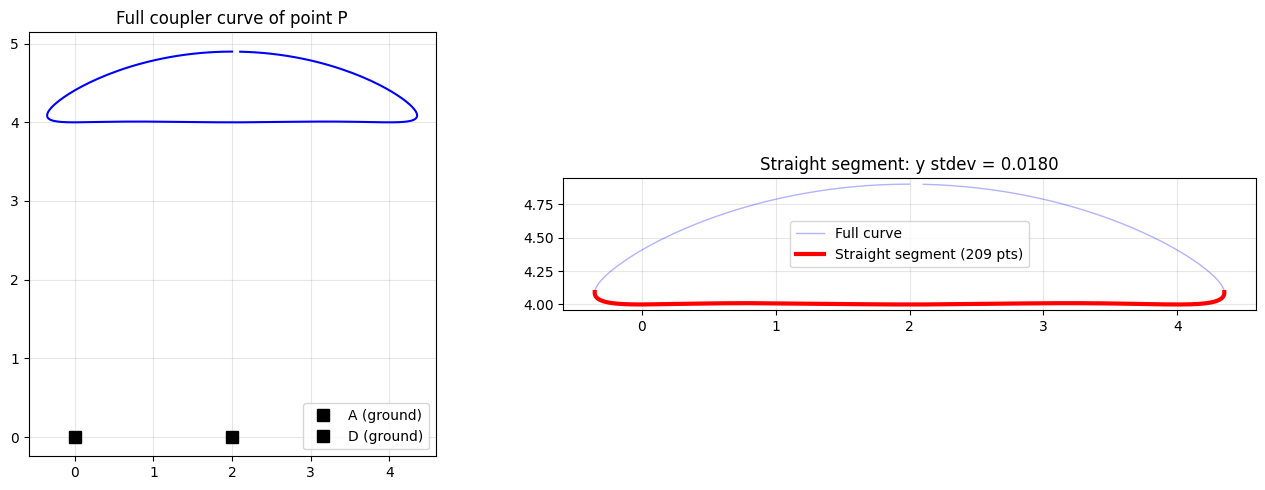

Straight segment: 209/300 points
  X range: 4.70
  Y stdev: 0.0180 (lower = straighter)


In [ ]:
# Simulate one full crank rotation
loci = list(hoeken.step(iterations=300))

# Extract the coupler point P trajectory
p_path = [(pos[-1][0], pos[-1][1]) for pos in loci if pos[-1][0] is not None]
px, py = zip(*p_path, strict=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full coupler curve
ax1.plot(px, py, 'b-', linewidth=1.5)
ax1.plot(0, 0, 'ks', markersize=8, label='A (ground)')
ax1.plot(2, 0, 'ks', markersize=8, label='D (ground)')
ax1.set_title('Full coupler curve of point P')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Highlight the straight segment (points near the minimum y)
y_min = min(py)
straight = [(x, y) for x, y in p_path if abs(y - y_min) < 0.1]
sx, sy = zip(*straight, strict=False)
ax2.plot(px, py, 'b-', linewidth=1, alpha=0.3, label='Full curve')
ax2.plot(sx, sy, 'r-', linewidth=3, label=f'Straight segment ({len(straight)} pts)')
ax2.set_title(f'Straight segment: y stdev = {statistics.stdev(sy):.4f}')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Straight segment: {len(straight)}/{len(p_path)} points')
print(f'  X range: {max(sx) - min(sx):.2f}')
print(f'  Y stdev: {statistics.stdev(sy):.4f} (lower = straighter)')

## 2. Mechanism Motion

Show the linkage in multiple positions to understand the motion.

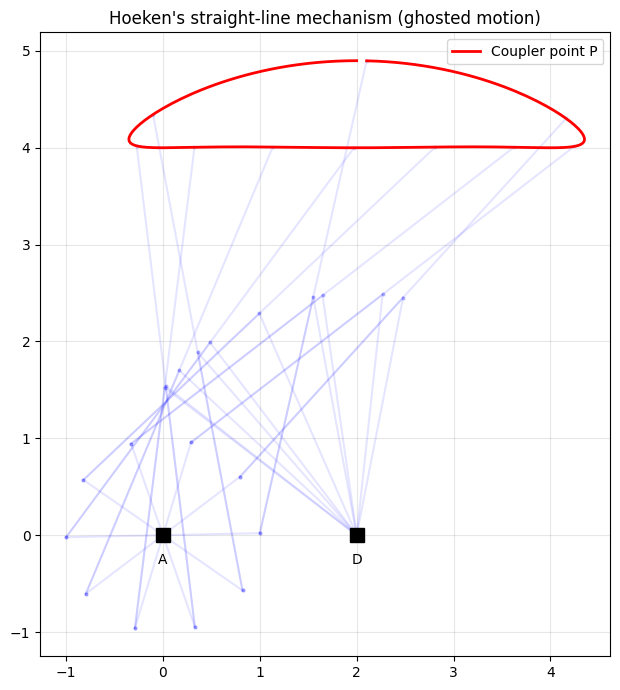

In [ ]:
hoeken.rebuild()
loci = list(hoeken.step(iterations=300))

fig, ax = plt.subplots(figsize=(10, 7))

# Draw ghosted linkage every 30th frame
for frame_idx in range(0, len(loci), 30):
    pos = loci[frame_idx]
    coords = {i: (pos[i][0], pos[i][1]) for i in range(len(pos))}
    if any(coords[i][0] is None for i in coords):
        continue
    # A=0, D=1, B=2, C=3, P=4
    for link in [(0,2), (2,3), (3,1), (2,4)]:
        xs = [coords[link[0]][0], coords[link[1]][0]]
        ys = [coords[link[0]][1], coords[link[1]][1]]
        ax.plot(xs, ys, 'b-o', alpha=0.1, markersize=2)

# Overlay coupler point trajectory
p_path = [(pos[-1][0], pos[-1][1]) for pos in loci if pos[-1][0] is not None]
px, py = zip(*p_path, strict=False)
ax.plot(px, py, 'r-', linewidth=2, label='Coupler point P')

ax.plot(0, 0, 'ks', markersize=10)
ax.plot(2, 0, 'ks', markersize=10)
ax.text(0, -0.3, 'A', ha='center', fontsize=10)
ax.text(2, -0.3, 'D', ha='center', fontsize=10)
ax.set_title("Hoeken's straight-line mechanism (ghosted motion)")
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Grashof Classification

The Grashof criterion determines whether the crank can rotate fully.
For a useful straight-line mechanism, we need **crank-rocker** (crank rotates, rocker oscillates).

In [ ]:
a, b, c, d = 1.0, 2.5, 2.5, 2.0
gt = grashof_check(a, b, c, d)
print(f'Link lengths: a={a}, b={b}, c={c}, d={d}')
print(f'Grashof type: {gt.name}')
print()
lengths = sorted([a, b, c, d])
print(f'Shortest + longest = {lengths[0] + lengths[3]:.1f}')
print(f'Sum of middle two  = {lengths[1] + lengths[2]:.1f}')
print(f'Grashof condition satisfied: {lengths[0] + lengths[3] <= lengths[1] + lengths[2]}')

Link lengths: a=1.0, b=2.5, c=2.5, d=2.0
Grashof type: GRASHOF_CRANK_ROCKER

Shortest + longest = 3.5
Sum of middle two  = 4.5
Grashof condition satisfied: True


## 4. Path Generation Synthesis

Instead of using known linkage parameters, we can synthesize a mechanism
from target points using Burmester theory. Here we specify 3 collinear
precision points and let the algorithm find four-bar linkages whose
coupler point passes through them — approximating a straight line.

In [ ]:
# Collinear precision points: the coupler should trace through these
# to approximate a straight horizontal line.
precision_points = [(-2.0, -1.0), (0.0, -1.0), (2.0, -1.0)]

result = path_generation(
    precision_points=precision_points,
    max_solutions=10,
    require_grashof=True,
    require_crank_rocker=True,
)

print(f'Found {len(result.raw_solutions)} crank-rocker solutions')
for i, sol in enumerate(result.raw_solutions[:5]):
    gt = grashof_check(sol.crank_length, sol.coupler_length,
                       sol.rocker_length, sol.ground_length)
    print(f'  [{i}] a={sol.crank_length:.2f} b={sol.coupler_length:.2f} '
          f'c={sol.rocker_length:.2f} d={sol.ground_length:.2f} -> {gt.name}')

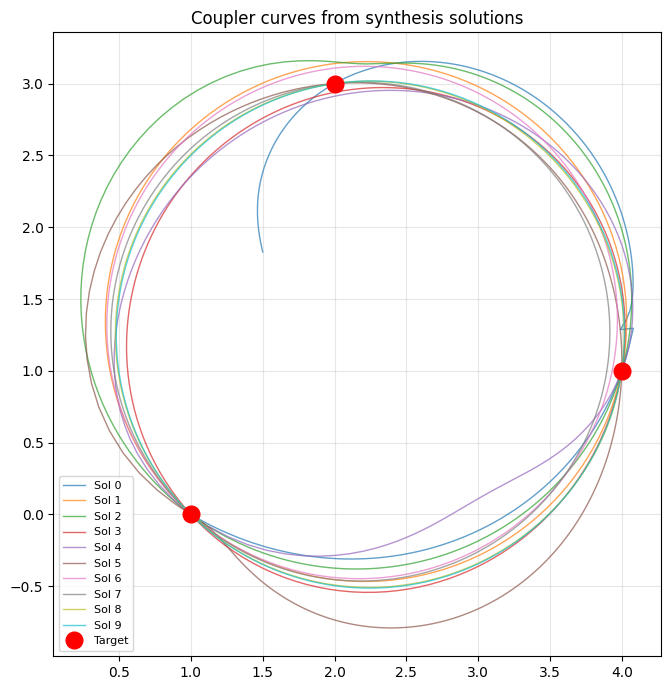

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, sol in enumerate(result.raw_solutions):
    try:
        lk = solution_to_linkage(sol, iterations=200)
        loci = list(lk.step(iterations=200))
        path = [(pos[-1][0], pos[-1][1]) for pos in loci if pos[-1][0] is not None]
        if path:
            cx, cy = zip(*path, strict=False)
            ax.plot(cx, cy, linewidth=1, alpha=0.7, label=f'Sol {i}')
    except Exception:
        continue

ax.plot(*zip(*precision_points, strict=False), 'ro', markersize=12, zorder=10, label='Target')
ax.set_title('Coupler curves from synthesis solutions')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Interactive Plotly Visualization

We reuse the components-based Hoeken linkage (which includes the coupler
point P) and build an interactive Plotly figure showing all joint paths.

In [ ]:
import plotly.graph_objects as go

# Simulate the components-based Hoeken linkage (which has coupler point P)
hoeken.rebuild()
loci = list(hoeken.step(iterations=300))

# Joint names: A=0, D=1, B=2, C=3, P=4
joint_names = [c.name for c in hoeken.components]

fig = go.Figure()

# Plot each joint's trajectory
colors = {'A': '#333', 'D': '#333', 'B': '#1565C0', 'C': '#1565C0', 'P': '#E53935'}
for j, name in enumerate(joint_names):
    xs = [frame[j][0] for frame in loci if frame[j][0] is not None]
    ys = [frame[j][1] for frame in loci if frame[j][1] is not None]
    fig.add_trace(go.Scatter(
        x=xs, y=ys, mode='lines',
        name=f'{name} path',
        line={'color': colors.get(name, '#999'),
              'width': 4 if name == 'P' else 1,
              'dash': 'solid' if name == 'P' else 'dot'},
        opacity=1.0 if name == 'P' else 0.5,
    ))

# Draw initial linkage configuration
pos0 = loci[0]
for link in [(0, 2), (2, 3), (3, 1), (2, 4)]:
    fig.add_trace(go.Scatter(
        x=[pos0[link[0]][0], pos0[link[1]][0]],
        y=[pos0[link[0]][1], pos0[link[1]][1]],
        mode='lines', line={'color': '#90CAF9', 'width': 6},
        showlegend=False, hoverinfo='skip',
    ))

# Mark ground pivots
for j in [0, 1]:
    fig.add_trace(go.Scatter(
        x=[pos0[j][0]], y=[pos0[j][1]],
        mode='markers', marker={'symbol': 'square', 'size': 12, 'color': '#333'},
        name=joint_names[j], showlegend=False,
    ))

fig.update_layout(
    title="Hoeken's straight-line mechanism (Plotly)",
    xaxis={'scaleanchor': 'y', 'scaleratio': 1, 'title': 'X'},
    yaxis={'title': 'Y'},
    plot_bgcolor='white', width=800, height=600,
)
fig.show()